# Diagnóstico de calidad, adecuación, cobertura y limitaciones de los datos

**Proyecto de Aprendizaje Automático (PAA) — UTEC / LIDIA 2026 · Predicción de siniestros viales**

Produce la evidencia que respalda el diagnóstico de datos exigido por el Entregable 2 de la guía
PAA (sección 5.2) y la sección *Metodología — datos* del informe (guía 6.1: calidad, cobertura,
representatividad, sesgos y restricciones de uso).

**Qué responde**

| Eje | Pregunta |
|---|---|
| Calidad | ¿Los registros son completos, consistentes y precisos para lo que se les va a pedir? |
| Cobertura | ¿Qué territorio, qué período y qué fracción de la unidad de análisis observan realmente? |
| Adecuación | ¿La variable objetivo y las variables disponibles sostienen el problema planteado? |
| Limitaciones | ¿Qué no puede afirmarse con estos datos y qué riesgos introduce cada decisión? |

**Alcance: Montevideo, 2021–2025.** Se diagnostican las tres fuentes que alimentan el conjunto de
modelado: el CSV crudo de siniestros heredado del PID, la capa de barrios de la Intendencia y la
serie climática de Open-Meteo. La unidad de análisis es **(día, barrio)**.

**Todo se recalcula desde las fuentes crudas**, incluida la asignación de cada siniestro a su
barrio. El diagnóstico no depende de que `data/processed/` esté construido; cuando lo está, la
sección 5 lo usa para **contrastar** su propia reconstrucción contra la salida del ETL. Esto lo
convierte en una verificación independiente de
[`preparacion_montevideo.ipynb`](preparacion_montevideo.ipynb), y no en un resumen de ella.

El notebook es de **solo lectura** sobre `data/`: no escribe ni reescribe ningún conjunto.

**Qué deja como artefacto.** Todas las tablas y figuras se escriben en
`experiments/diagnostico_datos/`, de modo que cada cifra citada en el informe pueda rastrearse
hasta un archivo del repositorio.

> **Nota sobre el alcance anterior.** Hasta 2026-09-02 este notebook diagnosticaba el país entero
> (224.694 siniestros, 2018–2025, celdas de 1 km) e incluía secciones sobre división cronológica,
> estabilidad del universo de zonas y elección de granularidad. Esas decisiones ya están tomadas
> —Montevideo, barrios, 2021+— y las secciones que las discutían se retiraron: son materia del
> notebook de modelado, no del diagnóstico. Los hallazgos que sobrevivieron al cambio de alcance
> se vuelven a calcular aquí sobre los datos vigentes, no se copian.

## 0. Configuración y trazabilidad de las fuentes

In [1]:
import hashlib
import importlib.metadata as md_meta
import json
import platform
import sys
import unicodedata
import zipfile
from datetime import datetime, timezone
from pathlib import Path

import holidays
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.patches import Polygon as PolyPatch
from matplotlib.path import Path as RutaPoligono
from pyproj import Transformer

# Raíz del repo: funciona sin importar desde dónde se abra el notebook
RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data" / "raw").is_dir())
DIR_CRUDO = RAIZ / "data" / "raw"
DIR_PROC = RAIZ / "data" / "processed"
RUTA_CSV = DIR_CRUDO / "uru_siniestros_unificado.csv"
RUTA_CLIMA = DIR_CRUDO / "clima_montevideo.csv"

DIR_SALIDA = RAIZ / "experiments" / "diagnostico_datos"
DIR_TABLAS = DIR_SALIDA / "tablas"
DIR_FIGURAS = DIR_SALIDA / "figuras"
for d in (DIR_TABLAS, DIR_FIGURAS):
    d.mkdir(parents=True, exist_ok=True)

# ── Alcance diagnosticado. Debe coincidir con preparacion_montevideo.ipynb ──
DEPARTAMENTO = "MONTEVIDEO"
FECHA_INICIO = "2021-01-01"
CRS_ORIGEN, CRS_DESTINO = "EPSG:32721", "EPSG:4326"
CAJA_UY = {"lat": (-35.5, -30.0), "lon": (-58.6, -53.0)}
PATRONES_BARRIOS = ["*barrio*.geojson", "*barrio*.json", "*barrio*.zip", "*barrio*.shp"]
CAMPOS_NOMBRE = ["NOMBRE", "BARRIO", "NOM_BARRIO", "nombre", "barrio", "name", "NOMBBARR"]
CATEGORIAS_FERIADO = ("public", "bank")
SEMILLA = 42

rng = np.random.default_rng(SEMILLA)
pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 40)
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 140, "savefig.bbox": "tight",
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 9,
})


def guardar_tabla(tabla, nombre, indice=False):
    """Escribe la tabla como CSV en experiments/ y la muestra en el notebook."""
    destino = DIR_TABLAS / f"{nombre}.csv"
    tabla.to_csv(destino, index=indice, encoding="utf-8")
    print(f"[tabla]  {destino.relative_to(RAIZ)}")
    display(tabla)


def guardar_figura(fig, nombre):
    destino = DIR_FIGURAS / f"{nombre}.png"
    fig.savefig(destino)
    print(f"[figura] {destino.relative_to(RAIZ)}")

Las tres fuentes se identifican por su *hash*. Si alguna se actualiza, el `sha256` cambia y las
cifras de este diagnóstico dejan de corresponder: es lo que permite detectar que hay que
volver a ejecutarlo.

In [2]:
def buscar_capa_barrios():
    for patron in PATRONES_BARRIOS:
        for ruta in sorted(DIR_CRUDO.glob(patron)):
            return ruta
    return None


RUTA_BARRIOS = buscar_capa_barrios()
if RUTA_BARRIOS is None:
    raise FileNotFoundError(
        "No se encontró la capa de barrios en data/raw/. El diagnóstico de alcance montevideano "
        "la necesita: ver la sección 4 de preparacion_montevideo.ipynb para cómo obtenerla."
    )

FUENTES = [("siniestros", RUTA_CSV), ("barrios", RUTA_BARRIOS), ("clima", RUTA_CLIMA)]
filas = []
for nombre, ruta in FUENTES:
    if not ruta.exists():
        filas.append((nombre, str(ruta.relative_to(RAIZ)), "AUSENTE", "", ""))
        continue
    filas.append((
        nombre, str(ruta.relative_to(RAIZ)), f"{ruta.stat().st_size / 1e6:.2f} MB",
        hashlib.sha256(ruta.read_bytes()).hexdigest(),
        datetime.fromtimestamp(ruta.stat().st_mtime).strftime("%Y-%m-%d %H:%M"),
    ))

procedencia = pd.DataFrame(filas, columns=["fuente", "archivo", "tamaño", "sha256", "modificado"])
paquetes = ["pandas", "numpy", "matplotlib", "holidays", "pyproj", "pyshp"]
entorno = pd.DataFrame(
    [("ejecutado", datetime.now(timezone.utc).astimezone().strftime("%Y-%m-%d %H:%M")),
     ("python", f"{sys.version.split()[0]} · {platform.system()} {platform.release()}")]
    + [(p, md_meta.version(p)) for p in paquetes], columns=["clave", "valor"])

guardar_tabla(procedencia, "00_procedencia")
guardar_tabla(entorno, "00b_entorno")

[tabla]  experiments\diagnostico_datos\tablas\00_procedencia.csv


,fuente,archivo,tamaño,sha256,modificado
0,siniestros,data\raw\uru_siniestros_unificado.csv,26.19 MB,48a8a7e8f06ed8aa1d138b9921995d81a2c86cb3858354...,2026-08-24 11:21
1,barrios,data\raw\barrios_montevideo.geojson,0.98 MB,a03e89278409ffff4b30e7ebea9aa22620d4ffae85897c...,2026-09-04 08:40
2,clima,data\raw\clima_montevideo.csv,0.08 MB,f40e6c3ccdeeb87aae40dcc5a9b685aa7471aefe50f446...,2026-09-02 10:30


[tabla]  experiments\diagnostico_datos\tablas\00b_entorno.csv


,clave,valor
0,ejecutado,2026-09-04 09:20
1,python,3.13.2 · Windows 10
2,pandas,3.0.5
3,numpy,2.5.2
4,matplotlib,3.11.1
5,holidays,0.103
6,pyproj,3.7.2
7,pyshp,3.1.6


## 1. Fuente, unidad de análisis y disponibilidad de las variables

In [3]:
# skipinitialspace: el CSV trae un espacio después de cada coma; los encabezados también
df_pais = pd.read_csv(RUTA_CSV, skipinitialspace=True, encoding="utf-8")
df_pais.columns = df_pais.columns.str.strip()
df_pais["Fecha"] = pd.to_datetime(df_pais["Fecha"], format="%m/%d/%Y")
for c in df_pais.select_dtypes(include="object").columns:
    df_pais[c] = df_pais[c].astype(str).str.strip()

COLS_CRUDAS = list(df_pais.columns)
print(f"archivo completo: {len(df_pais):,} registros × {len(COLS_CRUDAS)} columnas")
print(f"período del archivo: {df_pais['Fecha'].min():%Y-%m-%d} → {df_pais['Fecha'].max():%Y-%m-%d}")

esquema = pd.DataFrame({
    "tipo": df_pais.dtypes.astype(str),
    "no_nulos": df_pais.notna().sum(),
    "distintos": df_pais.nunique(),
    "ejemplo": df_pais.iloc[0].astype(str),
}).reset_index(names="columna")
guardar_tabla(esquema, "01_esquema_crudo")

archivo completo: 224,694 registros × 11 columnas
período del archivo: 2018-01-01 → 2025-12-31
[tabla]  experiments\diagnostico_datos\tablas\01_esquema_crudo.csv


C:\Users\victo\AppData\Local\Temp\ipykernel_1832\1312465157.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for c in df_pais.select_dtypes(include="object").columns:


,columna,tipo,no_nulos,distintos,ejemplo
0,Fecha,datetime64[us],224694,2922,2018-07-24 00:00:00
1,Calle,str,224693,23746,AVENIDA DIECIOCHO DE JULIO
2,Tipo de Siniestro,str,224694,9,ATROPELLO DE PEATÓN
3,Gravedad,str,224694,4,LEVE
4,Dia Semana,str,224694,7,MARTES
5,Hora,int64,224694,24,16
6,Departamento,str,224694,19,MONTEVIDEO
7,Localidad,str,224694,455,MONTEVIDEO
8,fixed,int64,224694,1,1
9,X,int64,224694,35532,575370


### 1.1 Recorte al alcance del proyecto

El archivo heredado del PID cubre el país entero desde 2018. El proyecto se acotó a **Montevideo
desde 2021** tras la reunión de seguimiento. La tabla siguiente deja explícito cuánto del archivo
sobrevive al recorte, que es el primer dato de cobertura del diagnóstico.

In [4]:
pasos = [("registros del archivo", len(df_pais))]
sel = df_pais[df_pais["Departamento"] == DEPARTAMENTO]
pasos.append((f"tras filtrar {DEPARTAMENTO}", len(sel)))
sel = sel[sel["Fecha"] >= pd.Timestamp(FECHA_INICIO)]
pasos.append((f"tras filtrar fecha >= {FECHA_INICIO}", len(sel)))

df = sel.copy().reset_index(drop=True)      # base del diagnóstico, antes de deduplicar
recorte = pd.DataFrame(pasos, columns=["paso", "registros"])
recorte["pct_del_archivo"] = (100 * recorte["registros"] / len(df_pais)).round(1)
guardar_tabla(recorte, "02_recorte_alcance")

FECHA_FIN = df["Fecha"].max()
DIAS = pd.date_range(FECHA_INICIO, FECHA_FIN, freq="D")
print(f"\nperíodo diagnosticado: {DIAS[0]:%Y-%m-%d} → {DIAS[-1]:%Y-%m-%d} ({len(DIAS):,} días)")

[tabla]  experiments\diagnostico_datos\tablas\02_recorte_alcance.csv


,paso,registros,pct_del_archivo
0,registros del archivo,224694,100.0
1,tras filtrar MONTEVIDEO,62427,27.8
2,tras filtrar fecha >= 2021-01-01,39676,17.7



período diagnosticado: 2021-01-01 → 2025-12-31 (1,826 días)


### 1.2 Unidad de análisis y disponibilidad temporal de las variables

La unidad es **(día, barrio)** y la variable objetivo es el **conteo de siniestros** en esa
combinación. La pregunta que gobierna la tabla siguiente es la que exige la guía (6.1): *¿esta
columna está disponible en el momento real de la predicción?* Todo lo que describe el siniestro
—hora, tipo, gravedad— **existe sólo después de que ocurrió**, así que no puede ser variable
predictora: sería mirar la respuesta. Se conserva en el diagnóstico como caracterización de la
fuente, no como insumo del modelo.

In [5]:
# La clasificación es una decisión del equipo, no un cálculo: se versiona como tabla para
# poder citarla y discutirla.
roles = pd.DataFrame(
    [
        ("Fecha", "día del siniestro", "sí", "eje temporal de la unidad de análisis"),
        ("X, Y", "coordenadas UTM 21S del siniestro", "sí", "definen el barrio por intersección"),
        ("Departamento", "atributo territorial", "sí", "sólo para el recorte; constante después"),
        ("Localidad", "atributo territorial", "parcial", "faltante encubierto; la zona sale del polígono"),
        ("Calle", "texto libre del lugar", "parcial", "alta cardinalidad; no se usa"),
        ("Dia Semana", "derivable de Fecha", "sí", "se usa para verificar el formato de fecha (2.3)"),
        ("Hora", "hora del siniestro ocurrido", "no", "posterior al evento; la unidad es el día"),
        ("Tipo de Siniestro", "clasificación del siniestro ocurrido", "no", "posterior al evento"),
        ("Gravedad", "consecuencia del siniestro ocurrido", "no", "posterior al evento"),
        ("fixed", "marca del proceso ETL del PID", "no", "constante: sin información"),
    ],
    columns=["columna", "qué es", "disponible antes del evento", "uso en el PAA"],
)
guardar_tabla(roles, "03_disponibilidad_variables")

exogenas = pd.DataFrame(
    [("clima (Open-Meteo)", "archivo histórico reanalizado", "sí",
      "disponible para cualquier fecha pasada; en producción exige pronóstico"),
     ("tipo_dia (calendario)", "entre_semana / fin_semana / feriado", "sí",
      "determinista: se conoce con años de anticipación")],
    columns=["variable exógena", "qué es", "disponible antes del evento", "observación"],
)
guardar_tabla(exogenas, "03b_disponibilidad_exogenas")

[tabla]  experiments\diagnostico_datos\tablas\03_disponibilidad_variables.csv


,columna,qué es,disponible antes del evento,uso en el PAA
0,Fecha,día del siniestro,sí,eje temporal de la unidad de análisis
1,"X, Y",coordenadas UTM 21S del siniestro,sí,definen el barrio por intersección
2,Departamento,atributo territorial,sí,sólo para el recorte; constante después
3,Localidad,atributo territorial,parcial,faltante encubierto; la zona sale del polígono
4,Calle,texto libre del lugar,parcial,alta cardinalidad; no se usa
5,Dia Semana,derivable de Fecha,sí,se usa para verificar el formato de fecha (2.3)
6,Hora,hora del siniestro ocurrido,no,posterior al evento; la unidad es el día
7,Tipo de Siniestro,clasificación del siniestro ocurrido,no,posterior al evento
8,Gravedad,consecuencia del siniestro ocurrido,no,posterior al evento
9,fixed,marca del proceso ETL del PID,no,constante: sin información


[tabla]  experiments\diagnostico_datos\tablas\03b_disponibilidad_exogenas.csv


,variable exógena,qué es,disponible antes del evento,observación
0,clima (Open-Meteo),archivo histórico reanalizado,sí,disponible para cualquier fecha pasada; en pro...
1,tipo_dia (calendario),entre_semana / fin_semana / feriado,sí,determinista: se conoce con años de anticipación


De once columnas del archivo, sólo **`Fecha`, `X` e `Y`** construyen la unidad de análisis y la
variable objetivo. Las tres columnas que describen el siniestro (`Hora`, `Tipo de Siniestro`,
`Gravedad`) son informativas para caracterizar la fuente pero **inutilizables como predictoras**.

La fila del clima merece una advertencia que el informe debe recoger: aquí se usa el **archivo
histórico reanalizado** de Open-Meteo, que para una fecha pasada da la observación. Un sistema en
producción no tendría eso, sino un **pronóstico**, con su propio error. El desempeño medido con
clima observado es, por tanto, una **cota optimista** del desempeño operativo.

## 2. Calidad

### 2.1 Completitud: nulos explícitos y faltantes encubiertos

El archivo no trae valores nulos: los faltantes vienen **codificados como texto** (`SIN DATOS` y
variantes). Contarlos como categoría sería subestimar el problema, así que se los busca
explícitamente. Se informa el país y el recorte por separado, porque la diferencia entre ambos es
en sí misma un resultado.

In [6]:
CENTINELAS = ("SIN DATOS", "NO SE INGRESO", "NO SE INGRESÓ", "SIN DATO")

filas = []
for col in df_pais.select_dtypes(include="object").columns:
    filas.append({
        "columna": col,
        "nulos": int(df[col].isna().sum()),
        "centinela_pais_%": round(100 * df_pais[col].isin(CENTINELAS).mean(), 2),
        "centinela_mvd_n": int(df[col].isin(CENTINELAS).sum()),
        "centinela_mvd_%": round(100 * df[col].isin(CENTINELAS).mean(), 2),
    })
completitud = pd.DataFrame(filas).sort_values("centinela_mvd_%", ascending=False)
guardar_tabla(completitud, "04_completitud")

[tabla]  experiments\diagnostico_datos\tablas\04_completitud.csv


C:\Users\victo\AppData\Local\Temp\ipykernel_1832\2376962209.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_pais.select_dtypes(include="object").columns:


,columna,nulos,centinela_pais_%,centinela_mvd_n,centinela_mvd_%
5,Localidad,0,17.91,1765,4.45
0,Calle,0,12.37,925,2.33
1,Tipo de Siniestro,0,0.01,10,0.03
2,Gravedad,0,0.00,0,0.00
3,Dia Semana,0,0.00,0,0.00
4,Departamento,0,0.00,0,0.00


El recorte a Montevideo **mejora sustancialmente la completitud**: las columnas afectadas por
faltantes encubiertos lo están mucho menos que en el país. El problema de calidad que dominaba el
diagnóstico nacional era, en buena medida, un problema del interior.

Ninguna de las columnas afectadas se usa como predictora —el barrio sale de la geometría, no del
texto de `Localidad`—, de modo que **no corresponde imputar**: los faltantes están en campos
descriptivos que el modelo no consume. Se declara el conteo en lugar de omitirlo.

### 2.2 Duplicados

Se cuentan como duplicados las filas idénticas en **todas** las columnas del archivo. Sin
identificador de siniestro no hay forma de distinguir con certeza un duplicado de carga de dos
siniestros reales con los mismos atributos; el peso de la evidencia lo da el tamaño del grupo
mayor.

In [7]:
dup_pais = df_pais.duplicated()
dup_mvd = df.duplicated()
grupos = df[df.duplicated(keep=False)].groupby(list(df.columns), dropna=False).size()

duplicados = pd.DataFrame(
    [("duplicados exactos en el archivo", f"{int(dup_pais.sum()):,}",
      f"{100 * dup_pais.mean():.2f} %"),
     ("duplicados exactos en el recorte", f"{int(dup_mvd.sum()):,}",
      f"{100 * dup_mvd.mean():.2f} %"),
     ("grupos con repetición (recorte)", f"{len(grupos):,}", ""),
     ("repeticiones en el grupo mayor", f"{int(grupos.max()) if len(grupos) else 0}", "")],
    columns=["indicador", "valor", "proporción"],
)
guardar_tabla(duplicados, "05_duplicados")

# Efecto sobre la cola alta del objetivo: el máximo por (día, barrio) antes y después
df_dedup = df.drop_duplicates().reset_index(drop=True)
print(f"\nregistros tras deduplicar el recorte: {len(df_dedup):,}")

[tabla]  experiments\diagnostico_datos\tablas\05_duplicados.csv


,indicador,valor,proporción
0,duplicados exactos en el archivo,347,0.15 %
1,duplicados exactos en el recorte,96,0.24 %
2,grupos con repetición (recorte),77,
3,repeticiones en el grupo mayor,10,



registros tras deduplicar el recorte: 39,580


El grupo mayor concentra varias copias byte a byte del **mismo** registro. Un siniestro no se
repite diez veces en la misma esquina, a la misma hora, con el mismo tipo y la misma gravedad: la
lectura es que se trata de un artefacto de carga, no de eventos distintos.

Su efecto se ve en la cola alta de la variable objetivo (sección 4.1): sin deduplicar, el máximo
de siniestros en un día y un barrio queda inflado por repeticiones. **El resto del diagnóstico usa
el recorte deduplicado.**

### 2.3 Consistencia interna

`Dia Semana` es redundante respecto de `Fecha`, y esa redundancia es útil: permite **verificar el
formato de fecha contra evidencia independiente del propio archivo**. Es una comprobación barata
que evita un error silencioso y grave — `05/06/2021` parsea con `%m/%d/%Y` y con `%d/%m/%Y`, y
da días distintos.

In [8]:
DIAS_ES = {0: "LUNES", 1: "MARTES", 2: "MIERCOLES", 3: "JUEVES",
           4: "VIERNES", 5: "SABADO", 6: "DOMINGO"}


def sin_tildes(serie):
    return serie.str.upper().map(
        lambda s: "".join(c for c in unicodedata.normalize("NFD", s)
                          if unicodedata.category(c) != "Mn"))


crudo_fecha = pd.read_csv(RUTA_CSV, skipinitialspace=True, encoding="utf-8", usecols=["Fecha"])
crudo_fecha = crudo_fecha["Fecha"].astype(str).str.strip()
observado = sin_tildes(df_pais["Dia Semana"])

filas = []
for fmt in ["%m/%d/%Y", "%d/%m/%Y"]:
    parsed = pd.to_datetime(crudo_fecha, format=fmt, errors="coerce")
    coincide = (parsed.dt.dayofweek.map(DIAS_ES) == observado)
    filas.append((fmt, int(parsed.isna().sum()), f"{100 * coincide.mean():.4f} %"))

consistencia = pd.DataFrame(filas, columns=["formato probado", "fechas no parseables",
                                            "coincidencia con 'Dia Semana'"])
guardar_tabla(consistencia, "06_consistencia")

otros = pd.DataFrame(
    [("Hora fuera de 0-23", int((~df_dedup["Hora"].between(0, 23)).sum())),
     ("valores distintos de 'fixed'", int(df_dedup["fixed"].nunique())),
     ("registros con Departamento != MONTEVIDEO", int((df_dedup["Departamento"] != DEPARTAMENTO).sum())),
     ("fechas fuera del período declarado", int((~df_dedup["Fecha"].between(DIAS[0], DIAS[-1])).sum()))],
    columns=["comprobación", "registros"],
)
guardar_tabla(otros, "06b_consistencia_otros")

[tabla]  experiments\diagnostico_datos\tablas\06_consistencia.csv


,formato probado,fechas no parseables,coincidencia con 'Dia Semana'
0,%m/%d/%Y,0,100.0000 %
1,%d/%m/%Y,133356,6.7955 %


[tabla]  experiments\diagnostico_datos\tablas\06b_consistencia_otros.csv


,comprobación,registros
0,Hora fuera de 0-23,0
1,valores distintos de 'fixed',1
2,registros con Departamento != MONTEVIDEO,0
3,fechas fuera del período declarado,0


Un solo formato explica el **100 %** de los días de la semana declarados y el otro falla en la
mayoría de los registros: el archivo es homogéneo y la fecha se parsea sin ambigüedad. Esto
**refuta la suposición del ETL del PID**, que probaba varios formatos en cascada
(`parsear_fecha_mixta`) asumiendo que el archivo los mezclaba.

`fixed` toma un único valor en todo el recorte: no aporta información y no puede usarse como
indicador de calidad de la geocodificación, aunque su nombre lo sugiera.

### 2.4 Precisión espacial

Interesa saber a qué se parecen las coordenadas: si están geocodificadas a la esquina o al tramo
de calle, la asignación a barrio es fiable; si estuvieran volcadas al centroide de la ciudad, no
lo sería.

In [9]:
xy = df_dedup.groupby(["X", "Y"]).size().sort_values(ascending=False)
mult5 = ((df_dedup["X"] % 5 == 0) & (df_dedup["Y"] % 5 == 0)).mean()

precision = pd.DataFrame(
    [("coordenadas múltiplo de 5 m", f"{100 * mult5:.2f} %"),
     ("coordenadas distintas", f"{len(xy):,}"),
     ("siniestros por coordenada (media)", f"{len(df_dedup) / len(xy):.1f}"),
     ("siniestros en la coordenada más repetida", f"{int(xy.iloc[0]):,}"),
     ("… como % del recorte", f"{100 * xy.iloc[0] / len(df_dedup):.2f} %"),
     ("las 10 coordenadas más repetidas concentran", f"{100 * xy.head(10).sum() / len(df_dedup):.2f} %"),
     ("rango X (m)", f"{df_dedup['X'].min():,} – {df_dedup['X'].max():,}"),
     ("rango Y (m)", f"{df_dedup['Y'].min():,} – {df_dedup['Y'].max():,}"),
     ("coordenadas nulas o <= 0", int(((df_dedup["X"] <= 0) | (df_dedup["Y"] <= 0)).sum()))],
    columns=["indicador", "valor"],
)
guardar_tabla(precision, "07_precision_espacial")

[tabla]  experiments\diagnostico_datos\tablas\07_precision_espacial.csv


,indicador,valor
0,coordenadas múltiplo de 5 m,100.00 %
1,coordenadas distintas,"8,088"
2,siniestros por coordenada (media),4.9
3,siniestros en la coordenada más repetida,122
4,… como % del recorte,0.31 %
5,las 10 coordenadas más repetidas concentran,1.97 %
6,rango X (m),"554,380 – 588,320"
7,rango Y (m),"6,134,505 – 6,157,850"
8,coordenadas nulas o <= 0,0


La resolución es de 5 m y los siniestros se reparten entre miles de coordenadas distintas, con
una concentración baja en la más repetida. Ese patrón es el de una geocodificación **a esquina o
tramo de calle**, no a un centroide genérico, y es lo que hace viable la asignación por
intersección punto-polígono de la sección 2.6.

La contrapartida, que hay que declarar: un punto ajustado a la esquina puede caer del lado
equivocado de un límite de barrio cuando ese límite corre por el eje de la calle. El error
afectaría a siniestros individuales cerca de los bordes, no al orden de magnitud por barrio.

### 2.5 Validez temporal

In [10]:
por_dia = df_dedup.groupby("Fecha").size().reindex(DIAS, fill_value=0)

validez = pd.DataFrame(
    [("días del período", f"{len(DIAS):,}"),
     ("días sin ningún siniestro", f"{int((por_dia == 0).sum()):,}"),
     ("mínimo diario", int(por_dia.min())),
     ("mediana diaria", float(por_dia.median())),
     ("máximo diario", int(por_dia.max())),
     ("fecha del mínimo", f"{por_dia.idxmin():%Y-%m-%d}"),
     ("fecha del máximo", f"{por_dia.idxmax():%Y-%m-%d}")],
    columns=["indicador", "valor"],
)
guardar_tabla(validez, "08_validez_temporal")

[tabla]  experiments\diagnostico_datos\tablas\08_validez_temporal.csv


,indicador,valor
0,días del período,"1,826"
1,días sin ningún siniestro,0
2,mínimo diario,4
3,mediana diaria,22.0
4,máximo diario,44
5,fecha del mínimo,2022-01-16
6,fecha del máximo,2025-12-11


No hay días vacíos ni saltos en el calendario: la serie diaria del departamento está completa. Un
día sin registros habría sido sospechoso de falla del sistema de carga más que de ausencia real de
siniestros, y no ocurre.

### 2.6 Calidad de la asignación a barrios

La zona sale de una **intersección punto-polígono** entre las coordenadas del siniestro y la capa
de barrios de la Intendencia. No se geocodifica ninguna dirección. Lo que hay que diagnosticar es
cuántos siniestros **no** caen en ningún polígono, y si la capa cubre lo que dice cubrir.

El código de lectura y asignación está deliberadamente duplicado respecto de
`preparacion_montevideo.ipynb`: así el diagnóstico verifica la asignación de forma independiente
en lugar de heredarla. Cuando se migre a `src/`, ambos deberían llamar a la misma función.

In [11]:
A_WGS84 = Transformer.from_crs(CRS_ORIGEN, CRS_DESTINO, always_xy=True)
A_UTM = Transformer.from_crs(CRS_DESTINO, CRS_ORIGEN, always_xy=True)


def leer_capa(ruta):
    """Devuelve [(nombre, [anillos]), ...] en las unidades del archivo."""
    if ruta.suffix.lower() in (".geojson", ".json"):
        datos = json.loads(ruta.read_text(encoding="utf-8"))
        salida = []
        for i, rasgo in enumerate(datos.get("features", [])):
            props = {k.upper(): v for k, v in (rasgo.get("properties") or {}).items()}
            nombre = next((str(props[c.upper()]) for c in CAMPOS_NOMBRE
                           if c.upper() in props and props[c.upper()]), f"zona_{i}")
            geo = rasgo.get("geometry") or {}
            if geo.get("type") == "Polygon":
                polis = [geo["coordinates"]]
            elif geo.get("type") == "MultiPolygon":
                polis = geo["coordinates"]
            else:
                continue
            salida.append((nombre, [np.asarray(a, float)[:, :2] for p in polis for a in p]))
        return salida

    import shapefile  # pyshp
    if ruta.suffix.lower() == ".zip":
        zf = zipfile.ZipFile(ruta)
        base = next(n[:-4] for n in zf.namelist() if n.lower().endswith(".shp"))
        abrir = lambda e: zf.open(base + e) if (base + e) in zf.namelist() else None
        lector = shapefile.Reader(shp=abrir(".shp"), dbf=abrir(".dbf"), shx=abrir(".shx"))
    else:
        lector = shapefile.Reader(str(ruta))
    campos = [c[0] for c in lector.fields[1:]]
    idx = next((campos.index(c) for c in CAMPOS_NOMBRE if c in campos), None)
    salida = []
    for i, sr in enumerate(lector.iterShapeRecords()):
        pts = np.asarray(sr.shape.points, float)
        cortes = list(sr.shape.parts) + [len(pts)]
        anillos = [pts[a:b] for a, b in zip(cortes[:-1], cortes[1:]) if b - a >= 4]
        if anillos:
            salida.append((str(sr.record[idx]) if idx is not None else f"zona_{i}", anillos))
    return salida


def preparar(capa):
    """Reproyecta a UTM si hace falta y separa anillos exteriores de agujeros."""
    out = []
    for nombre, anillos in capa:
        conv = []
        for a in anillos:
            x, y = a[:, 0], a[:, 1]
            if np.abs(x).max() <= 180 and np.abs(y).max() <= 90:
                x, y = A_UTM.transform(x, y)
            conv.append(np.column_stack([x, y]))
        areas = [abs(np.dot(a[:, 0], np.roll(a[:, 1], 1))
                     - np.dot(a[:, 1], np.roll(a[:, 0], 1))) / 2 for a in conv]
        ext, hue = [], []
        for k in np.argsort(areas)[::-1]:
            anillo = conv[k]
            if any(RutaPoligono(e).contains_point(anillo.mean(axis=0)) for e in ext):
                hue.append(anillo)
            else:
                ext.append(anillo)
        out.append((nombre, [RutaPoligono(e) for e in ext], [RutaPoligono(h) for h in hue]))
    return out


capa = leer_capa(RUTA_BARRIOS)
poligonos = preparar(capa)
print(f"capa: {RUTA_BARRIOS.name} · {len(capa)} polígonos · "
      f"{len({n for n, _ in capa})} nombres distintos")

capa: barrios_montevideo.geojson · 62 polígonos · 62 nombres distintos


In [12]:
puntos = df_dedup[["X", "Y"]].to_numpy(float)
zona = np.full(len(df_dedup), None, dtype=object)
for nombre, ext, hue in poligonos:
    libre = pd.isna(pd.Series(zona)).to_numpy()
    if not libre.any():
        break
    dentro = np.zeros(len(df_dedup), bool)
    for e in ext:
        dentro |= e.contains_points(puntos)
    for h in hue:
        dentro &= ~h.contains_points(puntos)
    zona[libre & dentro] = nombre

df_dedup = df_dedup.assign(barrio=zona)
sin_barrio = df_dedup["barrio"].isna()

calidad_capa = pd.DataFrame(
    [("polígonos en la capa", len(capa)),
     ("nombres distintos", len({n for n, _ in capa})),
     ("barrios con al menos un siniestro", int(df_dedup["barrio"].nunique())),
     ("siniestros asignados", f"{int((~sin_barrio).sum()):,}"),
     ("siniestros fuera de todo polígono", f"{int(sin_barrio.sum()):,}"),
     ("… como % del recorte", f"{100 * sin_barrio.mean():.2f} %")],
    columns=["indicador", "valor"],
)
guardar_tabla(calidad_capa, "09_calidad_capa_barrios")

if sin_barrio.any():
    fuera = df_dedup[sin_barrio]
    lat, lon = A_WGS84.transform(fuera["X"].to_numpy(float), fuera["Y"].to_numpy(float))
    detalle = pd.DataFrame({"Fecha": fuera["Fecha"].dt.strftime("%Y-%m-%d"),
                            "X": fuera["X"], "Y": fuera["Y"],
                            "latitud": np.round(lon, 6), "longitud": np.round(lat, 6),
                            "Calle": fuera["Calle"].values})
    guardar_tabla(detalle.head(30), "09b_siniestros_sin_barrio")

df_mvd = df_dedup[~sin_barrio].reset_index(drop=True)
print(f"\nbase del diagnóstico: {len(df_mvd):,} siniestros en {df_mvd['barrio'].nunique()} barrios")

[tabla]  experiments\diagnostico_datos\tablas\09_calidad_capa_barrios.csv


,indicador,valor
0,polígonos en la capa,62
1,nombres distintos,62
2,barrios con al menos un siniestro,62
3,siniestros asignados,"39,569"
4,siniestros fuera de todo polígono,11
5,… como % del recorte,0.03 %


[tabla]  experiments\diagnostico_datos\tablas\09b_siniestros_sin_barrio.csv


,Fecha,X,Y,latitud,longitud,Calle
7809,2022-11-04,558945,6150640,-34.784731,-56.355727,SIN DATOS
16044,2023-04-18,558985,6150535,-34.785675,-56.355282,VIA_PUBLICA
18851,2023-06-02,558945,6150640,-34.784731,-56.355727,RUTA 1 km. 22.000
21835,2023-09-10,558945,6150640,-34.784731,-56.355727,SIN DATOS
22304,2023-10-24,558945,6150640,-34.784731,-56.355727,RUTA 1 km. 22.000
22419,2023-12-02,558945,6150640,-34.784731,-56.355727,SIN DATOS
24138,2024-12-05,558945,6150640,-34.784731,-56.355727,SIN DATOS
24158,2024-11-26,558945,6150640,-34.784731,-56.355727,SIN DATOS
25394,2024-08-19,558945,6150640,-34.784731,-56.355727,SIN DATOS
31236,2025-02-09,558945,6150640,-34.784731,-56.355727,SIN DATOS



base del diagnóstico: 39,569 siniestros en 62 barrios


La fracción que queda fuera de todo polígono es la medida directa de fricción entre las dos
fuentes. Un valor bajo indica que la capa cubre el territorio donde efectivamente ocurren los
siniestros; los pocos casos restantes son puntos de borde —costa, límites departamentales— donde
la coordenada ajustada cae milimétricamente afuera.

**Se descartan y se documenta el conteo** en lugar de reasignarlos al barrio más cercano: la
reasignación introduciría una decisión arbitraria sobre casos que no cambian ninguna conclusión.

### 2.7 Calidad de la serie climática

El clima entra como variable exógena diaria para todo el departamento. Hay que verificar que
cubra el período completo, que no tenga huecos y que los valores sean físicamente plausibles
antes de darlo por bueno.

In [13]:
if not RUTA_CLIMA.exists():
    print("⚠️  No hay caché de clima en data/raw/: se omite el diagnóstico climático.")
    clima = None
else:
    clima = pd.read_csv(RUTA_CLIMA, parse_dates=["fecha"])
    cobertura = pd.Index(DIAS).isin(clima["fecha"])
    num = clima.select_dtypes(include=[np.number])

    calidad_clima = pd.DataFrame(
        [("días en la caché", f"{len(clima):,}"),
         ("días del período cubiertos", f"{int(cobertura.sum()):,} de {len(DIAS):,}"),
         ("días del período sin clima", int((~cobertura).sum())),
         ("fechas duplicadas", int(clima["fecha"].duplicated().sum())),
         ("celdas faltantes", int(clima.isna().sum().sum())),
         ("temperatura media fuera de -10..45 °C",
          int((~clima["temp_media"].between(-10, 45)).sum()) if "temp_media" in clima else "n/d"),
         ("precipitación negativa",
          int((clima["precipitacion_mm"] < 0).sum()) if "precipitacion_mm" in clima else "n/d")],
        columns=["indicador", "valor"],
    )
    guardar_tabla(calidad_clima, "10_calidad_clima")
    guardar_tabla(num.describe().round(2).reset_index(names="estadístico"), "10b_clima_resumen")

[tabla]  experiments\diagnostico_datos\tablas\10_calidad_clima.csv


,indicador,valor
0,días en la caché,"1,826"
1,días del período cubiertos,"1,826 de 1,826"
2,días del período sin clima,0
3,fechas duplicadas,0
4,celdas faltantes,0
5,temperatura media fuera de -10..45 °C,0
6,precipitación negativa,0


[tabla]  experiments\diagnostico_datos\tablas\10b_clima_resumen.csv


,estadístico,temp_media,temp_max,temp_min,precipitacion_mm,lluvia_mm,viento_max_kmh,codigo_wmo
0,count,1826.00,1826.00,1826.00,1826.00,1826.00,1826.00,1826.00
1,mean,17.03,19.82,14.43,2.41,2.41,25.81,26.50
2,std,5.01,5.61,4.87,6.57,6.57,8.06,26.79
3,min,4.90,6.40,1.10,0.00,0.00,7.90,0.00
4,25%,12.70,15.10,10.60,0.00,0.00,19.90,3.00
5,50%,17.20,20.00,14.50,0.00,0.00,25.00,3.00
6,75%,21.10,23.80,18.40,1.20,1.20,30.68,53.00
7,max,31.70,38.80,27.50,105.30,105.30,62.90,65.00


Sin faltantes y con el período completo, **no corresponde imputar** el clima. El rango de valores
es el esperable para Montevideo.

Una limitación de diseño, no de calidad: se usa **una sola serie para todo el departamento**. A
resolución diaria las variables meteorológicas son prácticamente uniformes sobre unos 200 km²
urbanos, de modo que el supuesto es razonable, pero significa que el clima **no puede explicar
ninguna diferencia entre barrios**: aporta sólo variación temporal, la misma para las 62 zonas.
Esto tiene consecuencias en la sección 4.3.

## 3. Cobertura

### 3.1 Cobertura temporal

In [14]:
anual = df_mvd.groupby(df_mvd["Fecha"].dt.year).size().rename("siniestros").to_frame()
anual["media_diaria"] = (anual["siniestros"] /
                         df_mvd.groupby(df_mvd["Fecha"].dt.year)["Fecha"].nunique()).round(2)
anual["var_pct"] = (100 * anual["siniestros"].pct_change()).round(1)
guardar_tabla(anual.reset_index(names="año"), "11_cobertura_temporal_anual")

mensual = df_mvd.groupby([df_mvd["Fecha"].dt.year, df_mvd["Fecha"].dt.month]).size().unstack(0)
mensual.index.name = "mes"
guardar_tabla(mensual.reset_index(), "11b_cobertura_mensual")

[tabla]  experiments\diagnostico_datos\tablas\11_cobertura_temporal_anual.csv


,año,siniestros,media_diaria,var_pct
0,2021,6893,18.88,NaN
1,2022,7665,21.00,11.2
2,2023,7873,21.57,2.7
3,2024,8398,22.95,6.7
4,2025,8740,23.95,4.1


[tabla]  experiments\diagnostico_datos\tablas\11b_cobertura_mensual.csv


Fecha,mes,2021,2022,2023,2024,2025
0,1,453,459,515,587,565
1,2,429,522,569,574,611
2,3,512,663,681,655,729
3,4,459,614,566,707,744
4,5,552,670,683,775,814
5,6,552,680,689,694,746
6,7,626,654,687,707,720
7,8,653,682,717,709,778
8,9,628,690,632,709,742
9,10,647,655,715,751,763


#### El filtro de 2021 no elimina el régimen de la pandemia

El recorte empieza en 2021 «para que el modelo no vea la pandemia». Conviene comprobar si eso
efectivamente ocurre: en Uruguay la ola de COVID y las restricciones de movilidad fueron en el
**primer semestre de 2021**, ya dentro del período diagnosticado.

In [15]:
anio = df_mvd["Fecha"].dt.year
primer_sem = df_mvd["Fecha"].dt.month <= 6
a0 = int(anio.min())

n_ini = int(((anio == a0) & primer_sem).sum())
d_ini = pd.date_range(f"{a0}-01-01", f"{a0}-06-30").size
n_ref = int(((anio > a0) & primer_sem).sum())
d_ref = sum(pd.date_range(f"{a}-01-01", f"{a}-06-30").size
            for a in range(a0 + 1, int(anio.max()) + 1))
m_ini, m_ref = n_ini / d_ini, n_ref / d_ref

pandemia = pd.DataFrame(
    [(f"ene-jun {a0}", f"{n_ini:,}", d_ini, round(m_ini, 2)),
     (f"ene-jun {a0 + 1}-{int(anio.max())}", f"{n_ref:,}", d_ref, round(m_ref, 2)),
     ("diferencia", "", "", f"{100 * (m_ini / m_ref - 1):+.1f} %")],
    columns=["período", "siniestros", "días", "media diaria"],
)
guardar_tabla(pandemia, "12_pandemia_residual")

[tabla]  experiments\diagnostico_datos\tablas\12_pandemia_residual.csv


,período,siniestros,días,media diaria
0,ene-jun 2021,"2,957",181,16.34
1,ene-jun 2022-2025,"15,512",725,21.4
2,diferencia,,,-23.6 %


[figura] experiments\diagnostico_datos\figuras\fig1_cobertura_temporal.png


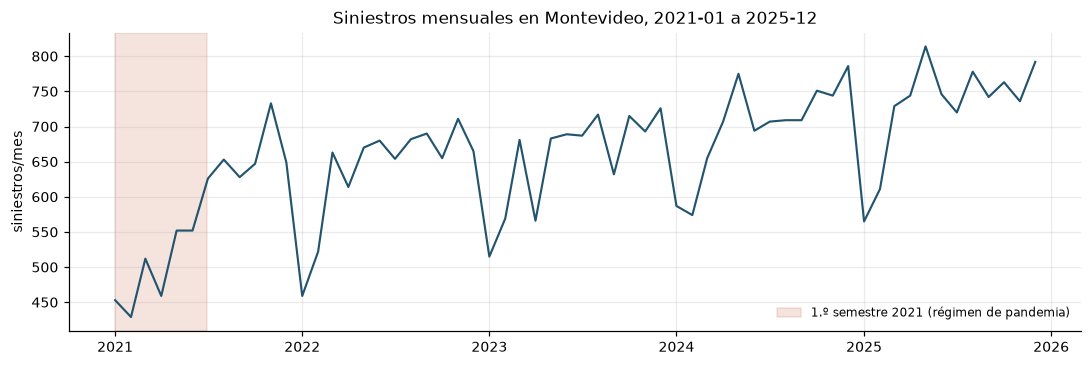

In [16]:
serie_m = df_mvd.set_index("Fecha").resample("MS").size()
fig, ax = plt.subplots(figsize=(10, 3.4))
ax.plot(serie_m.index, serie_m.to_numpy(), color="#22546e", linewidth=1.4)
ax.axvspan(pd.Timestamp(f"{a0}-01-01"), pd.Timestamp(f"{a0}-06-30"),
           color="#c96a4a", alpha=0.18, label=f"1.º semestre {a0} (régimen de pandemia)")
ax.set_title(f"Siniestros mensuales en {DEPARTAMENTO.title()}, {DIAS[0]:%Y-%m} a {DIAS[-1]:%Y-%m}")
ax.set_ylabel("siniestros/mes")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
guardar_figura(fig, "fig1_cobertura_temporal")
plt.show()

El primer semestre de 2021 tiene una siniestralidad marcadamente inferior a la de los mismos meses
de los años siguientes. **La justificación del filtro no se sostiene con los datos**: el recorte
excluye 2020 pero conserva el semestre más afectado por las restricciones.

El equipo decidió mantener 2021 completo. La consecuencia queda declarada aquí: el conjunto de
entrenamiento contiene un tramo con un régimen de movilidad que no volverá a repetirse, y eso
sesga a la baja cualquier tasa histórica estimada sobre los primeros meses de la serie. La
alternativa —empezar en 2021-07-01— cuesta seis meses de datos y es un cambio de una línea en el
notebook de preparación.

### 3.2 Cobertura territorial: los barrios

In [17]:
por_barrio = (df_mvd.groupby("barrio").size().rename("siniestros")
              .sort_values(ascending=False).to_frame())
por_barrio["dias_con_siniestro"] = df_mvd.groupby("barrio")["Fecha"].nunique()
por_barrio["pct_dias_con_siniestro"] = (100 * por_barrio["dias_con_siniestro"] / len(DIAS)).round(1)
por_barrio["pct_del_total"] = (100 * por_barrio["siniestros"] / len(df_mvd)).round(2)
guardar_tabla(por_barrio.reset_index(), "13_cobertura_barrios")

acum = por_barrio["siniestros"].cumsum() / por_barrio["siniestros"].sum()
resumen_terr = pd.DataFrame(
    [("barrios de la capa", len(capa)),
     ("barrios con al menos un siniestro", len(por_barrio)),
     ("siniestros — mínimo por barrio", int(por_barrio["siniestros"].min())),
     ("siniestros — mediana por barrio", int(por_barrio["siniestros"].median())),
     ("siniestros — máximo por barrio", int(por_barrio["siniestros"].max())),
     ("razón máximo/mínimo", f"{por_barrio['siniestros'].max() / por_barrio['siniestros'].min():.1f}×"),
     ("barrios que acumulan el 50 % de los siniestros", int((acum <= 0.50).sum() + 1)),
     ("barrios que acumulan el 90 % de los siniestros", int((acum <= 0.90).sum() + 1))],
    columns=["indicador", "valor"],
)
guardar_tabla(resumen_terr, "13b_concentracion_territorial")

[tabla]  experiments\diagnostico_datos\tablas\13_cobertura_barrios.csv


,barrio,siniestros,dias_con_siniestro,pct_dias_con_siniestro,pct_del_total
0,UNION,1939,1157,63.4,4.90
1,CORDON,1694,1091,59.7,4.28
2,AGUADA,1204,870,47.6,3.04
3,CENTRO,1197,863,47.3,3.03
4,MERCADO MODELO Y BOLIVAR,1138,835,45.7,2.88
...,...,...,...,...,...
57,MALVIN NORTE,270,253,13.9,0.68
58,PALERMO,261,242,13.3,0.66
59,JACINTO VERA,249,235,12.9,0.63
60,BARRIO SUR,241,225,12.3,0.61


[tabla]  experiments\diagnostico_datos\tablas\13b_concentracion_territorial.csv


,indicador,valor
0,barrios de la capa,62
1,barrios con al menos un siniestro,62
2,siniestros — mínimo por barrio,225
3,siniestros — mediana por barrio,570
4,siniestros — máximo por barrio,1939
5,razón máximo/mínimo,8.6×
6,barrios que acumulan el 50 % de los siniestros,19
7,barrios que acumulan el 90 % de los siniestros,49


[figura] experiments\diagnostico_datos\figuras\fig2_cobertura_territorial.png


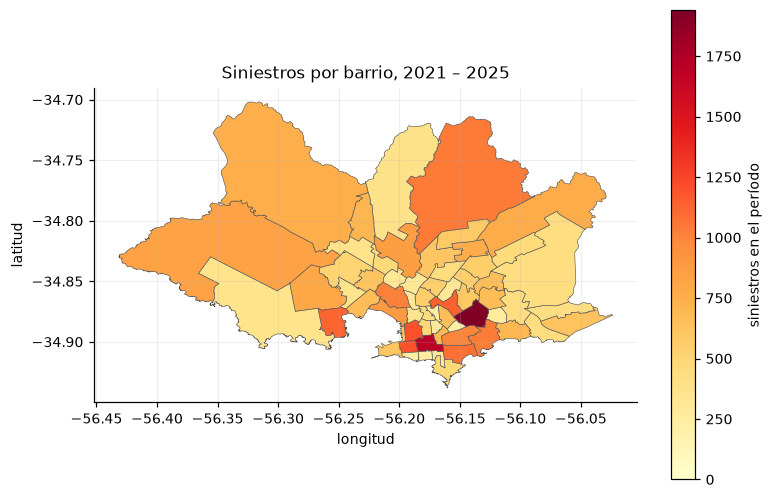

In [18]:
act = por_barrio["siniestros"].to_dict()
vmax = max(act.values())
cmap = plt.get_cmap("YlOrRd")

fig, ax = plt.subplots(figsize=(7.2, 5.6))
for nombre, anillos in capa:
    for a in anillos:
        xy = a[:, :2]
        if np.abs(xy[:, 0]).max() > 180:            # viene en UTM: pasar a lon/lat
            lon, lat = A_WGS84.transform(xy[:, 0], xy[:, 1])
            xy = np.column_stack([lon, lat])
        v = act.get(nombre, 0)
        ax.add_patch(PolyPatch(xy, closed=True, facecolor=cmap(v / vmax),
                               edgecolor="#555555", linewidth=0.4))
ax.autoscale_view()
ax.set_aspect("equal")
ax.set_title(f"Siniestros por barrio, {DIAS[0]:%Y} – {DIAS[-1]:%Y}")
ax.set_xlabel("longitud"); ax.set_ylabel("latitud"); ax.grid(alpha=0.2)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, vmax))
fig.colorbar(sm, ax=ax, label="siniestros en el período", shrink=0.8)
fig.tight_layout()
guardar_figura(fig, "fig2_cobertura_territorial")
plt.show()

Los 62 barrios están representados: **ninguno queda sin siniestros**, lo que elimina el problema
que tenía la grilla de 1 km, donde decenas de celdas registraban un único evento en cinco años y
volvían inviable cualquier reserva de zonas.

La actividad sigue estando muy concentrada —la razón entre el barrio más y el menos activo es de
casi un orden de magnitud—, pero ahora **todos los barrios tienen soporte suficiente** para
estimarles una tasa. Esa es la diferencia que hace viable el experimento del «megamodelo»
evaluado en zonas no vistas.

Una limitación de representatividad que conviene declarar: el mapa refleja **dónde se registran**
siniestros, no dónde son más probables por unidad de exposición. Sin datos de tránsito no se puede
normalizar por volumen de vehículos, de modo que un barrio muy transitado aparecerá arriba aunque
su riesgo por viaje sea bajo.

### 3.3 Cobertura de la unidad de análisis: el panel día × barrio

In [19]:
BARRIOS = sorted(df_mvd["barrio"].unique())
idx = pd.MultiIndex.from_product([DIAS, BARRIOS], names=["fecha", "barrio"])
y = (df_mvd.groupby(["Fecha", "barrio"]).size()
     .reindex(idx, fill_value=0).rename("n_siniestros"))
M = y.to_numpy().reshape(len(DIAS), len(BARRIOS))
assert M.sum() == len(df_mvd), "se perdieron siniestros al armar el panel"

no_cero = int((M > 0).sum())
panel_tab = pd.DataFrame(
    [("filas del panel (días × barrios)", f"{M.size:,}"),
     ("filas con al menos un siniestro", f"{no_cero:,}"),
     ("densidad (filas no nulas)", f"{100 * no_cero / M.size:.2f} %"),
     ("ceros", f"{100 * (1 - no_cero / M.size):.2f} %"),
     ("media de siniestros por fila", f"{M.mean():.4f}"),
     ("máximo en una fila", int(M.max()))],
    columns=["indicador", "valor"],
)
guardar_tabla(panel_tab, "14_panel_dia_barrio")

[tabla]  experiments\diagnostico_datos\tablas\14_panel_dia_barrio.csv


,indicador,valor
0,filas del panel (días × barrios),"113,212"
1,filas con al menos un siniestro,"31,747"
2,densidad (filas no nulas),28.04 %
3,ceros,71.96 %
4,media de siniestros por fila,0.3495
5,máximo en una fila,7


El panel es **mucho más denso** que el que producía la grilla de 1 km. Sigue habiendo mayoría de
ceros —es un fenómeno raro observado en ventanas de un día— pero ya no en el régimen extremo que
obligaba a tratar el objetivo como casi binario.

Esto cambia el diseño del modelado: con esta densidad, una pérdida de conteo (Poisson o Tweedie)
tiene material suficiente para trabajar y **no hace falta balancear**, decisión que se toma en el
notebook de modelado y no aquí.

### 3.4 Cobertura de las variables exógenas

In [20]:
fer = holidays.country_holidays("UY", years=range(DIAS[0].year, DIAS[-1].year + 1),
                                categories=CATEGORIAS_FERIADO)
fer_def = holidays.country_holidays("UY", years=range(DIAS[0].year, DIAS[-1].year + 1))

es_feriado = pd.Series(DIAS.date, index=DIAS).map(lambda d: d in fer)
es_finde = pd.Series(DIAS.dayofweek >= 5, index=DIAS)
tipo_dia = pd.Series(np.select([es_feriado, es_finde], ["feriado", "fin_semana"],
                               default="entre_semana"), index=DIAS, name="tipo_dia")

cal = tipo_dia.value_counts().rename_axis("tipo_dia").reset_index(name="días")
cal["pct"] = (100 * cal["días"] / len(DIAS)).round(1)
cal["media_siniestros_dia"] = cal["tipo_dia"].map(
    por_dia.reindex(DIAS).groupby(tipo_dia).mean().round(2))
guardar_tabla(cal, "15_cobertura_calendario")

omitidos = sorted(set(fer) - set(fer_def))
omitidos = [d for d in omitidos if DIAS[0].date() <= d <= DIAS[-1].date()]
guardar_tabla(pd.DataFrame(
    [("feriados con categories=('public','bank')", len([d for d in fer if DIAS[0].date() <= d <= DIAS[-1].date()])),
     ("feriados con la configuración por defecto", len([d for d in fer_def if DIAS[0].date() <= d <= DIAS[-1].date()])),
     ("días que la configuración por defecto omite", len(omitidos))],
    columns=["configuración de `holidays`", "días en el período"]), "16_feriados")

if omitidos:
    guardar_tabla(pd.DataFrame({"fecha": [str(d) for d in omitidos],
                                "nombre": [fer[d] for d in omitidos]}).head(40),
                  "16b_feriados_omitidos_por_defecto")

[tabla]  experiments\diagnostico_datos\tablas\15_cobertura_calendario.csv


,tipo_dia,días,pct,media_siniestros_dia
0,entre_semana,1232,67.5,23.75
1,fin_semana,504,27.6,17.73
2,feriado,90,4.9,15.41


[tabla]  experiments\diagnostico_datos\tablas\16_feriados.csv


,configuración de `holidays`,días en el período
0,"feriados con categories=('public','bank')",90
1,feriados con la configuración por defecto,25
2,días que la configuración por defecto omite,65


[tabla]  experiments\diagnostico_datos\tablas\16b_feriados_omitidos_por_defecto.csv


,fecha,nombre
0,2021-01-06,Día de los Niños
1,2021-02-15,Carnaval
2,2021-02-16,Carnaval
3,2021-03-29,Semana de Turismo
4,2021-03-30,Semana de Turismo
5,2021-03-31,Semana de Turismo
6,2021-04-01,Semana de Turismo
7,2021-04-02,Semana de Turismo
8,2021-04-19,Desembarco de los 33 Orientales
9,2021-05-17,Batalla de Las Piedras


**El calendario está cubierto y el problema que este diagnóstico detectó en su versión anterior
está resuelto.** La configuración por omisión de `holidays` para Uruguay omite Carnaval y Semana de
Turismo —los dos períodos de mayor alteración de la movilidad del año—; el ETL vigente usa
`categories=("public", "bank")`, que sí los incluye.

La media de siniestros por tipo de día muestra que la variable discrimina: los feriados y los
fines de semana no se comportan como los días hábiles. Cuánto de la varianza total explica eso es
la pregunta de la sección 4.3.

**El clima está integrado** (sección 2.7), lo que cierra el otro hueco que el diagnóstico anterior
reportaba como abierto.

## 4. Adecuación

### 4.1 La variable objetivo

In [21]:
vals, cuentas = np.unique(M, return_counts=True)
dist = pd.DataFrame({"n_siniestros": vals, "filas": cuentas})
dist["pct"] = (100 * dist["filas"] / M.size).round(3)
guardar_tabla(dist, "17_distribucion_objetivo")

media, var = M.mean(), M.var()
disp = pd.DataFrame(
    [("media", round(float(media), 4)),
     ("varianza", round(float(var), 4)),
     ("índice de dispersión (var/media)", round(float(var / media), 3)),
     ("máximo", int(M.max())),
     ("% de filas en cero", f"{100 * (M == 0).mean():.2f} %"),
     ("% de filas con 1", f"{100 * (M == 1).mean():.2f} %"),
     ("% de filas con 2 o más", f"{100 * (M >= 2).mean():.2f} %")],
    columns=["indicador", "valor"],
)
guardar_tabla(disp, "18_dispersion_objetivo")

[tabla]  experiments\diagnostico_datos\tablas\17_distribucion_objetivo.csv


,n_siniestros,filas,pct
0,0,81465,71.958
1,1,25332,22.376
2,2,5248,4.636
3,3,974,0.860
4,4,158,0.140
5,5,26,0.023
6,6,6,0.005
7,7,3,0.003


[tabla]  experiments\diagnostico_datos\tablas\18_dispersion_objetivo.csv


,indicador,valor
0,media,0.3495
1,varianza,0.3957
2,índice de dispersión (var/media),1.132
3,máximo,7
4,% de filas en cero,71.96 %
5,% de filas con 1,22.38 %
6,% de filas con 2 o más,5.67 %


El índice de dispersión cercano a 1 indica que la varianza casi iguala a la media, que es la firma
de un proceso de **Poisson**. La consecuencia para el protocolo de evaluación es directa: las
métricas deben medir **calibración y ordenamiento** de una intensidad esperada, no exactitud
puntual del conteo. Un error absoluto medio sobre un objetivo así premia predecir siempre cerca de
cero y no informa nada útil.

La recomendación que se deriva —y que el notebook de modelado debe implementar— es **desvianza de
Poisson** como métrica principal, acompañada de calibración por estrato de actividad.

### 4.2 ¿Cuánta señal temporal hay realmente?

Esta es la pregunta que más condiciona el modelado, y la que este diagnóstico respondió en su
versión nacional con celdas de 1 km. **Se recalcula íntegramente sobre los barrios**, porque una
conclusión obtenida con otra granularidad no se hereda: al agregar celdas en barrios sube el
volumen por zona y la señal podría aparecer donde antes no estaba.

El contraste correcto no es contra cero, sino contra lo que produciría el **puro azar**: se
simulan series de Poisson con la misma tasa media de cada barrio y se compara la autocorrelación
observada contra la banda que generan esas simulaciones.

In [22]:
def acf(x, k):
    x = np.asarray(x, float) - np.mean(x)
    den = float((x * x).sum())
    return float((x[:-k] * x[k:]).sum() / den) if den > 0 else np.nan


N_SIM = 400          # simulaciones por barrio para estimar la banda nula
ACF_POR_REZAGO = {}  # se reutiliza en la figura, para no simular dos veces

filas = []
for k in (1, 7):
    obs = np.array([acf(M[:, j], k) for j in range(M.shape[1])])
    banda_sup = np.array([
        np.nanpercentile([acf(rng.poisson(M[:, j].mean(), M.shape[0]), k)
                          for _ in range(N_SIM)], 97.5)
        for j in range(M.shape[1])])
    ACF_POR_REZAGO[k] = (obs, banda_sup)
    filas.append((k, round(float(np.nanmedian(obs)), 4), round(float(np.nanmax(obs)), 4),
                  round(float(np.nanmean(banda_sup)), 4),
                  int((obs > banda_sup).sum()), round(0.025 * M.shape[1], 1)))

senal = pd.DataFrame(filas, columns=[
    "rezago", "ACF mediana por barrio", "ACF máxima por barrio",
    "banda nula Poisson (p97,5 media)", "barrios por encima de la banda",
    "barrios esperables por azar"])
guardar_tabla(senal, "19_senal_temporal_barrios")

[tabla]  experiments\diagnostico_datos\tablas\19_senal_temporal_barrios.csv


,rezago,ACF mediana por barrio,ACF máxima por barrio,"banda nula Poisson (p97,5 media)",barrios por encima de la banda,barrios esperables por azar
0,1,0.0137,0.0724,0.0449,7,1.6
1,7,0.0101,0.0838,0.0455,8,1.6


In [23]:
serie_dep = M.sum(axis=1).astype(float)
res_cal = serie_dep - pd.Series(serie_dep, index=DIAS).groupby(tipo_dia).transform("mean").to_numpy()

agregada = pd.DataFrame(
    [("serie cruda del departamento", round(acf(serie_dep, 1), 4), round(acf(serie_dep, 7), 4)),
     ("residuo tras descontar tipo_dia", round(acf(res_cal, 1), 4), round(acf(res_cal, 7), 4))],
    columns=["serie", "ACF rezago 1", "ACF rezago 7"],
)
guardar_tabla(agregada, "20_senal_serie_agregada")

# Varianza de la serie diaria del departamento explicada por bloques de calendario
sd = pd.DataFrame({"y": serie_dep}, index=DIAS)
sd["tipo_dia"] = tipo_dia
sd["mes"] = DIAS.month
sd["dow"] = DIAS.dayofweek
sstot = float(((sd["y"] - sd["y"].mean()) ** 2).sum())
filas = []
for nombre, cols in [("tipo_dia", ["tipo_dia"]), ("día de la semana", ["dow"]),
                     ("mes", ["mes"]), ("tipo_dia + mes", ["tipo_dia", "mes"]),
                     ("día de la semana + mes", ["dow", "mes"])]:
    pred = sd.groupby(cols)["y"].transform("mean")
    filas.append((nombre, round(100 * (1 - float(((sd["y"] - pred) ** 2).sum()) / sstot), 1)))
guardar_tabla(pd.DataFrame(filas, columns=["bloque de calendario", "% de varianza explicada"]),
              "20b_varianza_calendario")

[tabla]  experiments\diagnostico_datos\tablas\20_senal_serie_agregada.csv


,serie,ACF rezago 1,ACF rezago 7
0,serie cruda del departamento,0.2379,0.3459
1,residuo tras descontar tipo_dia,0.2438,0.2427


[tabla]  experiments\diagnostico_datos\tablas\20b_varianza_calendario.csv


,bloque de calendario,% de varianza explicada
0,tipo_dia,21.0
1,día de la semana,19.5
2,mes,9.0
3,tipo_dia + mes,30.2
4,día de la semana + mes,30.8


[figura] experiments\diagnostico_datos\figuras\fig3_senal_temporal.png


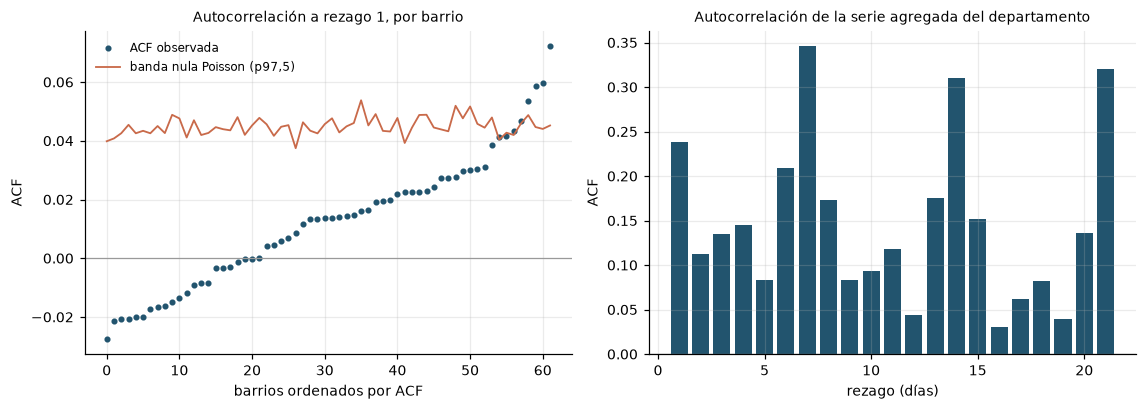

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 3.8))

k = 1
obs, banda = ACF_POR_REZAGO[k]        # calculados en la celda anterior
orden = np.argsort(obs)
ax1.plot(obs[orden], "o", ms=3, color="#22546e", label="ACF observada")
ax1.plot(banda[orden], "-", color="#c96a4a", lw=1.2, label="banda nula Poisson (p97,5)")
ax1.axhline(0, color="#999999", lw=0.8)
ax1.set_title(f"Autocorrelación a rezago {k}, por barrio", fontsize=9)
ax1.set_xlabel("barrios ordenados por ACF"); ax1.set_ylabel("ACF")
ax1.legend(frameon=False, fontsize=8)

lags = np.arange(1, 22)
ax2.bar(lags, [acf(serie_dep, l) for l in lags], color="#22546e")
ax2.axhline(0, color="#999999", lw=0.8)
ax2.set_title("Autocorrelación de la serie agregada del departamento", fontsize=9)
ax2.set_xlabel("rezago (días)"); ax2.set_ylabel("ACF")

fig.tight_layout()
guardar_figura(fig, "fig3_senal_temporal")
plt.show()

**En la enorme mayoría de los barrios no hay señal temporal de corto plazo.** La autocorrelación
mediana cae muy por debajo de la banda que produciría un Poisson de la misma tasa. El hallazgo del
diagnóstico nacional **se sostiene tras el cambio de granularidad**: agregar celdas en barrios sube
el volumen por zona, pero no hace aparecer persistencia día a día donde no la había.

Conviene, sin embargo, no redondear el resultado a «no hay nada». Los barrios que superan la banda
son **más de los que produciría el azar** —al percentil 97,5 se esperarían del orden de 1,6 de 62—,
así que en una minoría de barrios parece haber algo de estructura temporal real. Lo que dice el
diagnóstico es que **su magnitud es despreciable para el modelado**: incluso la autocorrelación más
alta observada explica menos del 1 % de la varianza de esa serie. La distinción importa porque una
cosa es «no se detecta señal» y otra «no existe»; lo que estos datos sostienen es lo primero, con
la salvedad de que lo poco que se detecta no alcanza para construir una variable útil.

**A nivel del departamento sí hay señal, y es de calendario.** La serie agregada muestra
autocorrelación clara, con un pico característico en el rezago 7 —estacionalidad semanal— que la
variable `tipo_dia` captura en parte. Lo que quede de autocorrelación en el residuo tras descontar
el calendario es persistencia no explicada: días buenos y días malos que ninguna de las variables
disponibles anticipa.

**Consecuencia de modelado, enunciada sin adornos:** una regla de persistencia por zona («ayer
hubo, hoy habrá») no tiene fundamento en estos datos. La línea base defendible es **tasa histórica
del barrio × factor de calendario**, y cualquier modelo más complejo debe justificarse contra ella
con el mismo protocolo.

### 4.3 ¿Qué puede aportar cada bloque de variables?

Antes de construir modelos conviene saber cuánto hay para ganar con cada familia de variables. Se
compara la **desvianza de Poisson** de cuatro predictores, todos ellos **oráculos calculados en
muestra**: a cada uno se le entrega directamente la media empírica del grupo correspondiente. Por
eso cada valor es una **cota superior** de lo que ese bloque de información puede lograr — ningún
modelo real que use sólo esas variables lo va a superar.

In [25]:
def desvianza(y_obs, mu):
    mu = np.clip(np.asarray(mu, float), 1e-12, None)
    y_obs = np.asarray(y_obs, float)
    pos = y_obs > 0
    t = np.zeros_like(y_obs)
    t[pos] = y_obs[pos] * np.log(y_obs[pos] / mu[pos])
    return float(2 * np.sum(t - (y_obs - mu)) / y_obs.size)


plano = M.ravel().astype(float)
g = plano.mean()
media_dia = np.repeat(M.mean(axis=1), M.shape[1])          # varía por día, igual en todo barrio
media_barrio = np.tile(M.mean(axis=0), M.shape[0])         # varía por barrio, igual todo el año

d0 = desvianza(plano, np.full_like(plano, g))
filas = []
for nombre, mu in [
    ("constante global (sin información)", np.full_like(plano, g)),
    ("sólo variables de día (clima + calendario) — techo", media_dia),
    ("sólo tasa histórica del barrio", media_barrio),
    ("barrio × día", media_barrio * (media_dia / g)),
]:
    d = desvianza(plano, mu)
    filas.append((nombre, round(d, 5), f"{100 * (d / d0 - 1):+.1f} %"))
guardar_tabla(pd.DataFrame(filas, columns=["información disponible", "desvianza de Poisson",
                                           "mejora sobre la constante"]),
              "21_aporte_bloques_variables")

vt = plano.var()
guardar_tabla(pd.DataFrame(
    [("varianza total del objetivo", round(float(vt), 5), "100,0 %"),
     ("entre barrios (varianza de las medias por barrio)", round(float(M.mean(axis=0).var()), 5),
      f"{100 * M.mean(axis=0).var() / vt:.1f} %"),
     ("entre días (varianza de las medias por día)", round(float(M.mean(axis=1).var()), 5),
      f"{100 * M.mean(axis=1).var() / vt:.2f} %")],
    columns=["componente", "varianza", "% de la total"]), "21b_descomposicion_varianza")

[tabla]  experiments\diagnostico_datos\tablas\21_aporte_bloques_variables.csv


,información disponible,desvianza de Poisson,mejora sobre la constante
0,constante global (sin información),0.94110,+0.0 %
1,sólo variables de día (clima + calendario) — t...,0.90784,-3.5 %
2,sólo tasa histórica del barrio,0.85280,-9.4 %
3,barrio × día,0.81954,-12.9 %


[tabla]  experiments\diagnostico_datos\tablas\21b_descomposicion_varianza.csv


,componente,varianza,% de la total
0,varianza total del objetivo,0.39573,"100,0 %"
1,entre barrios (varianza de las medias por barrio),0.03476,8.8 %
2,entre días (varianza de las medias por día),0.01130,2.85 %


El resultado tiene una consecuencia práctica inmediata y conviene no suavizarla.

**Las variables exógenas previstas —clima, día de la semana, feriados— son todas variables de
día.** Ninguna distingue un barrio de otro: para una fecha dada, los 62 barrios reciben
exactamente los mismos valores. Su techo conjunto es la fila «sólo variables de día», y es
modesto. La identidad del barrio, en cambio, aporta bastante más.

**Un modelo construido sólo con clima y calendario predeciría el mismo número para todos los
barrios cada día**, que es precisamente lo que el producto no puede hacer. Hace falta al menos una
variable de nivel de zona —la tasa histórica del barrio, ajustada sólo con datos de
entrenamiento—, y ese es el aporte que el notebook de modelado tiene que construir primero.

La descomposición de varianza dice lo mismo por otra vía: la variación **entre barrios** pesa
bastante más que la variación **entre días**.

### 4.4 Adecuación al objetivo del producto

In [26]:
adecuacion = pd.DataFrame(
    [("¿Se puede predecir el conteo diario por barrio?", "Sí",
      "el panel tiene densidad suficiente y el objetivo es de tipo Poisson"),
     ("¿Se puede predecir dónde ocurrirá el próximo siniestro?", "No",
      "a nivel de barrio-día no hay persistencia sobre el azar (4.2)"),
     ("¿Se puede ordenar barrios por riesgo esperado?", "Sí",
      "la tasa histórica por barrio es estable y aporta la mayor parte de la señal (4.3)"),
     ("¿Se puede estimar riesgo por unidad de exposición?", "No",
      "no hay datos de tránsito: sólo se observa el conteo, no la exposición"),
     ("¿Se puede modelar por gravedad o franja horaria?", "No con el conjunto vigente",
      "el ETL descarta esas columnas; exige volver a ejecutarlo"),
     ("¿Se puede evaluar en barrios no vistos al entrenar?", "Sí",
      "los 62 barrios tienen soporte; ninguna variable identifica al barrio")],
    columns=["pregunta", "respuesta", "fundamento"],
)
guardar_tabla(adecuacion, "22_adecuacion_objetivo")

[tabla]  experiments\diagnostico_datos\tablas\22_adecuacion_objetivo.csv


,pregunta,respuesta,fundamento
0,¿Se puede predecir el conteo diario por barrio?,Sí,el panel tiene densidad suficiente y el objeti...
1,¿Se puede predecir dónde ocurrirá el próximo s...,No,a nivel de barrio-día no hay persistencia sobr...
2,¿Se puede ordenar barrios por riesgo esperado?,Sí,la tasa histórica por barrio es estable y apor...
3,¿Se puede estimar riesgo por unidad de exposic...,No,no hay datos de tránsito: sólo se observa el c...
4,¿Se puede modelar por gravedad o franja horaria?,No con el conjunto vigente,el ETL descarta esas columnas; exige volver a ...
5,¿Se puede evaluar en barrios no vistos al entr...,Sí,los 62 barrios tienen soporte; ninguna variabl...


La segunda y la cuarta fila son las que acotan honestamente el alcance del producto. El sistema
puede **ordenar y calibrar riesgo esperado por barrio**, que es lo que sirve para asignar recursos
de fiscalización; no puede **anticipar siniestros individuales**, y no hay dato que lo permita.
Presentarlo de otro modo ante el tribunal sería insostenible.

## 5. Coherencia con el conjunto de modelado

El diagnóstico reconstruyó el panel desde las fuentes crudas, de forma independiente del ETL. Si
`data/processed/` está construido, comparar ambas reconstrucciones es una verificación cruzada
real: una discrepancia significa que uno de los dos notebooks tiene un error.

In [27]:
RUTA_PANEL = DIR_PROC / "panel_diario_montevideo.csv"
if not RUTA_PANEL.exists():
    print("data/processed/ no está construido: se omite la verificación cruzada.")
    print("Ejecutá preparacion_montevideo.ipynb y volvé a correr esta celda.")
else:
    etl = pd.read_csv(RUTA_PANEL, parse_dates=["fecha"])
    comp = pd.DataFrame(
        [("filas del panel", f"{M.size:,}", f"{len(etl):,}",
          "coincide" if M.size == len(etl) else "DISCREPANCIA"),
         ("siniestros totales", f"{int(M.sum()):,}", f"{int(etl['n_siniestros'].sum()):,}",
          "coincide" if int(M.sum()) == int(etl["n_siniestros"].sum()) else "DISCREPANCIA"),
         ("zonas", f"{len(BARRIOS):,}", f"{etl['zona_id'].nunique():,}",
          "coincide" if len(BARRIOS) == etl["zona_id"].nunique() else "DISCREPANCIA"),
         ("días", f"{len(DIAS):,}", f"{etl['fecha'].nunique():,}",
          "coincide" if len(DIAS) == etl["fecha"].nunique() else "DISCREPANCIA"),
         ("máximo del objetivo", int(M.max()), int(etl["n_siniestros"].max()),
          "coincide" if int(M.max()) == int(etl["n_siniestros"].max()) else "DISCREPANCIA")],
        columns=["comprobación", "diagnóstico (recalculado)", "ETL (data/processed)", "resultado"],
    )
    guardar_tabla(comp, "23_coherencia_etl")
    if (comp["resultado"] == "DISCREPANCIA").any():
        print("\n⚠️  Hay discrepancias: uno de los dos notebooks está mal. Revisar antes de citar "
              "cualquier cifra en el informe.")

[tabla]  experiments\diagnostico_datos\tablas\23_coherencia_etl.csv


,comprobación,diagnóstico (recalculado),ETL (data/processed),resultado
0,filas del panel,"113,212","113,212",coincide
1,siniestros totales,"39,569","39,569",coincide
2,zonas,62,62,coincide
3,días,"1,826","1,826",coincide
4,máximo del objetivo,7,7,coincide


## 6. Limitaciones y riesgos

Cada fila remite a la sección que la sustenta. La última no tiene sección porque **no es medible
con estos datos**, y decirlo es parte del diagnóstico.

In [28]:
limitaciones = pd.DataFrame(
    [
        ("Régimen de pandemia dentro del período", "3.1",
         "El 1.º semestre de 2021 tiene siniestralidad marcadamente menor. Sesga a la baja las "
         "tasas estimadas sobre el arranque de la serie.",
         "Declararlo; o mover el inicio a 2021-07-01 (una línea en el ETL)."),
        ("Sin señal temporal de corto plazo por barrio", "4.2",
         "Descarta las reglas de persistencia y acota lo que cualquier modelo puede lograr.",
         "Línea base = tasa del barrio × calendario; justificar todo modelo contra ella."),
        ("Variables exógenas sin variación espacial", "2.7, 4.3",
         "Clima y calendario son iguales para los 62 barrios cada día: no explican diferencias "
         "entre zonas.",
         "Construir la tasa histórica del barrio, ajustada sólo con entrenamiento."),
        ("Clima observado, no pronosticado", "1.2",
         "En producción habría pronóstico, con su propio error. El desempeño medido es una cota "
         "optimista.",
         "Declararlo en el informe; si se puede, evaluar con pronóstico diferido."),
        ("Sin datos de exposición (tránsito)", "3.2, 4.4",
         "Se modela el conteo observado, no el riesgo por viaje. Un barrio muy transitado aparece "
         "arriba aunque sea seguro por unidad de exposición.",
         "Limitar las afirmaciones a conteo esperado; no hablar de 'peligrosidad'."),
        ("Duplicados exactos en la fuente", "2.2",
         "Inflaban la cola alta del objetivo con repeticiones del mismo registro.",
         "Eliminados; criterio declarado. Revisar si la fuente se actualiza."),
        ("Faltantes encubiertos como texto", "2.1",
         "Afectan a columnas descriptivas, no a las que consume el modelo.",
         "No se imputa; se declara el conteo."),
        ("Siniestros fuera de todo polígono", "2.6",
         "Fricción entre la geocodificación y los límites de barrio.",
         "Se descartan y se documenta el conteo."),
        ("Catálogo de barrios y estratos definidos sobre todo el período", "3.2",
         "Usan información posterior al corte de entrenamiento. Fuga leve pero real.",
         "Recalcular el estrato sólo con entrenamiento antes de reservar zonas."),
        ("Subregistro de siniestros", "—",
         "El archivo contiene los siniestros registrados; la fracción no registrada es "
         "desconocida y probablemente no uniforme entre barrios.",
         "No es medible con estos datos. Declararlo como amenaza a la validez."),
    ],
    columns=["limitación", "sección", "por qué importa", "cómo se trata"],
)
guardar_tabla(limitaciones, "24_limitaciones")

[tabla]  experiments\diagnostico_datos\tablas\24_limitaciones.csv


,limitación,sección,por qué importa,cómo se trata
0,Régimen de pandemia dentro del período,3.1,El 1.º semestre de 2021 tiene siniestralidad m...,Declararlo; o mover el inicio a 2021-07-01 (un...
1,Sin señal temporal de corto plazo por barrio,4.2,Descarta las reglas de persistencia y acota lo...,Línea base = tasa del barrio × calendario; jus...
2,Variables exógenas sin variación espacial,"2.7, 4.3",Clima y calendario son iguales para los 62 bar...,"Construir la tasa histórica del barrio, ajusta..."
3,"Clima observado, no pronosticado",1.2,"En producción habría pronóstico, con su propio...","Declararlo en el informe; si se puede, evaluar..."
4,Sin datos de exposición (tránsito),"3.2, 4.4","Se modela el conteo observado, no el riesgo po...",Limitar las afirmaciones a conteo esperado; no...
5,Duplicados exactos en la fuente,2.2,Inflaban la cola alta del objetivo con repetic...,Eliminados; criterio declarado. Revisar si la ...
6,Faltantes encubiertos como texto,2.1,"Afectan a columnas descriptivas, no a las que ...",No se imputa; se declara el conteo.
7,Siniestros fuera de todo polígono,2.6,Fricción entre la geocodificación y los límite...,Se descartan y se documenta el conteo.
8,Catálogo de barrios y estratos definidos sobre...,3.2,Usan información posterior al corte de entrena...,Recalcular el estrato sólo con entrenamiento a...
9,Subregistro de siniestros,—,El archivo contiene los siniestros registrados...,No es medible con estos datos. Declararlo como...


La última fila merece énfasis porque afecta a la interpretación del mapa y de cualquier
ordenamiento de barrios: **el subregistro no es medible con los propios datos**. Que una parte
apreciable de los registros no tenga lesionados sugiere una cobertura amplia, pero no lo prueba, y
si la propensión a registrar variara entre barrios, el ordenamiento estaría sesgado de una forma
que este diagnóstico no puede detectar. Cuantificarlo exigiría una fuente externa de contraste que
el proyecto no tiene.

## 7. Artefactos generados

In [29]:
tablas = sorted(DIR_TABLAS.glob("*.csv"))
figuras = sorted(DIR_FIGURAS.glob("*.png"))
artefactos = pd.DataFrame(
    [(f"tablas/{t.name}", f"{t.stat().st_size / 1024:.1f} kB") for t in tablas]
    + [(f"figuras/{f.name}", f"{f.stat().st_size / 1024:.1f} kB") for f in figuras],
    columns=["artefacto", "tamaño"],
)
guardar_tabla(artefactos, "25_artefactos")
print(f"\n{len(tablas)} tablas y {len(figuras)} figuras en "
      f"{DIR_SALIDA.relative_to(RAIZ)}")

[tabla]  experiments\diagnostico_datos\tablas\25_artefactos.csv


,artefacto,tamaño
0,tablas/00_procedencia.csv,0.4 kB
1,tablas/00b_entorno.csv,0.2 kB
2,tablas/01_esquema_crudo.csv,0.4 kB
3,tablas/02_recorte_alcance.csv,0.1 kB
4,tablas/03_disponibilidad_variables.csv,0.8 kB
5,tablas/03b_disponibilidad_exogenas.csv,0.3 kB
6,tablas/04_completitud.csv,0.2 kB
7,tablas/05_duplicados.csv,0.2 kB
8,tablas/06_consistencia.csv,0.1 kB
9,tablas/06b_consistencia_otros.csv,0.2 kB



36 tablas y 3 figuras en experiments\diagnostico_datos


Cada cifra citada en la sección *Metodología — datos* del informe debe remitir a uno de estos
archivos. Si alguna no puede rastrearse hasta acá, es que no está respaldada.

**Antes de citar este diagnóstico, verificar que los `sha256` de la tabla `00_procedencia` sean los
de las fuentes vigentes.** Si alguna fuente cambió, hay que volver a ejecutar el notebook: las
cifras de esta corrida dejarían de corresponder.